In [1]:
%%javascript
MathJax.Hub.Config({
    TeX: { equationNumbers: { autoNumber: "AMS" } }
});

<IPython.core.display.Javascript object>

Prove
>TS, on the other hand would sample actions 1, 2, or 3,
with probabilities approximately equal to 0.82, 0, and 0.18, respectively.
In each case, this is the probability that the random estimate drawn for
the action exceeds those drawn for other actions. Since these estimates
are drawn from posterior distributions, each of these probabilities is
also equal to the probability that the corresponding action is optimal,
conditioned on observed history.

from https://web.stanford.edu/~bvr/pubs/TS_Tutorial.pdf Chapter 3 **Thompson Sampling for the Bernoulli Bandit**.

Given the three beta distributions, take three samples from each distribbution, and simulate the probability of which sample being the largest.

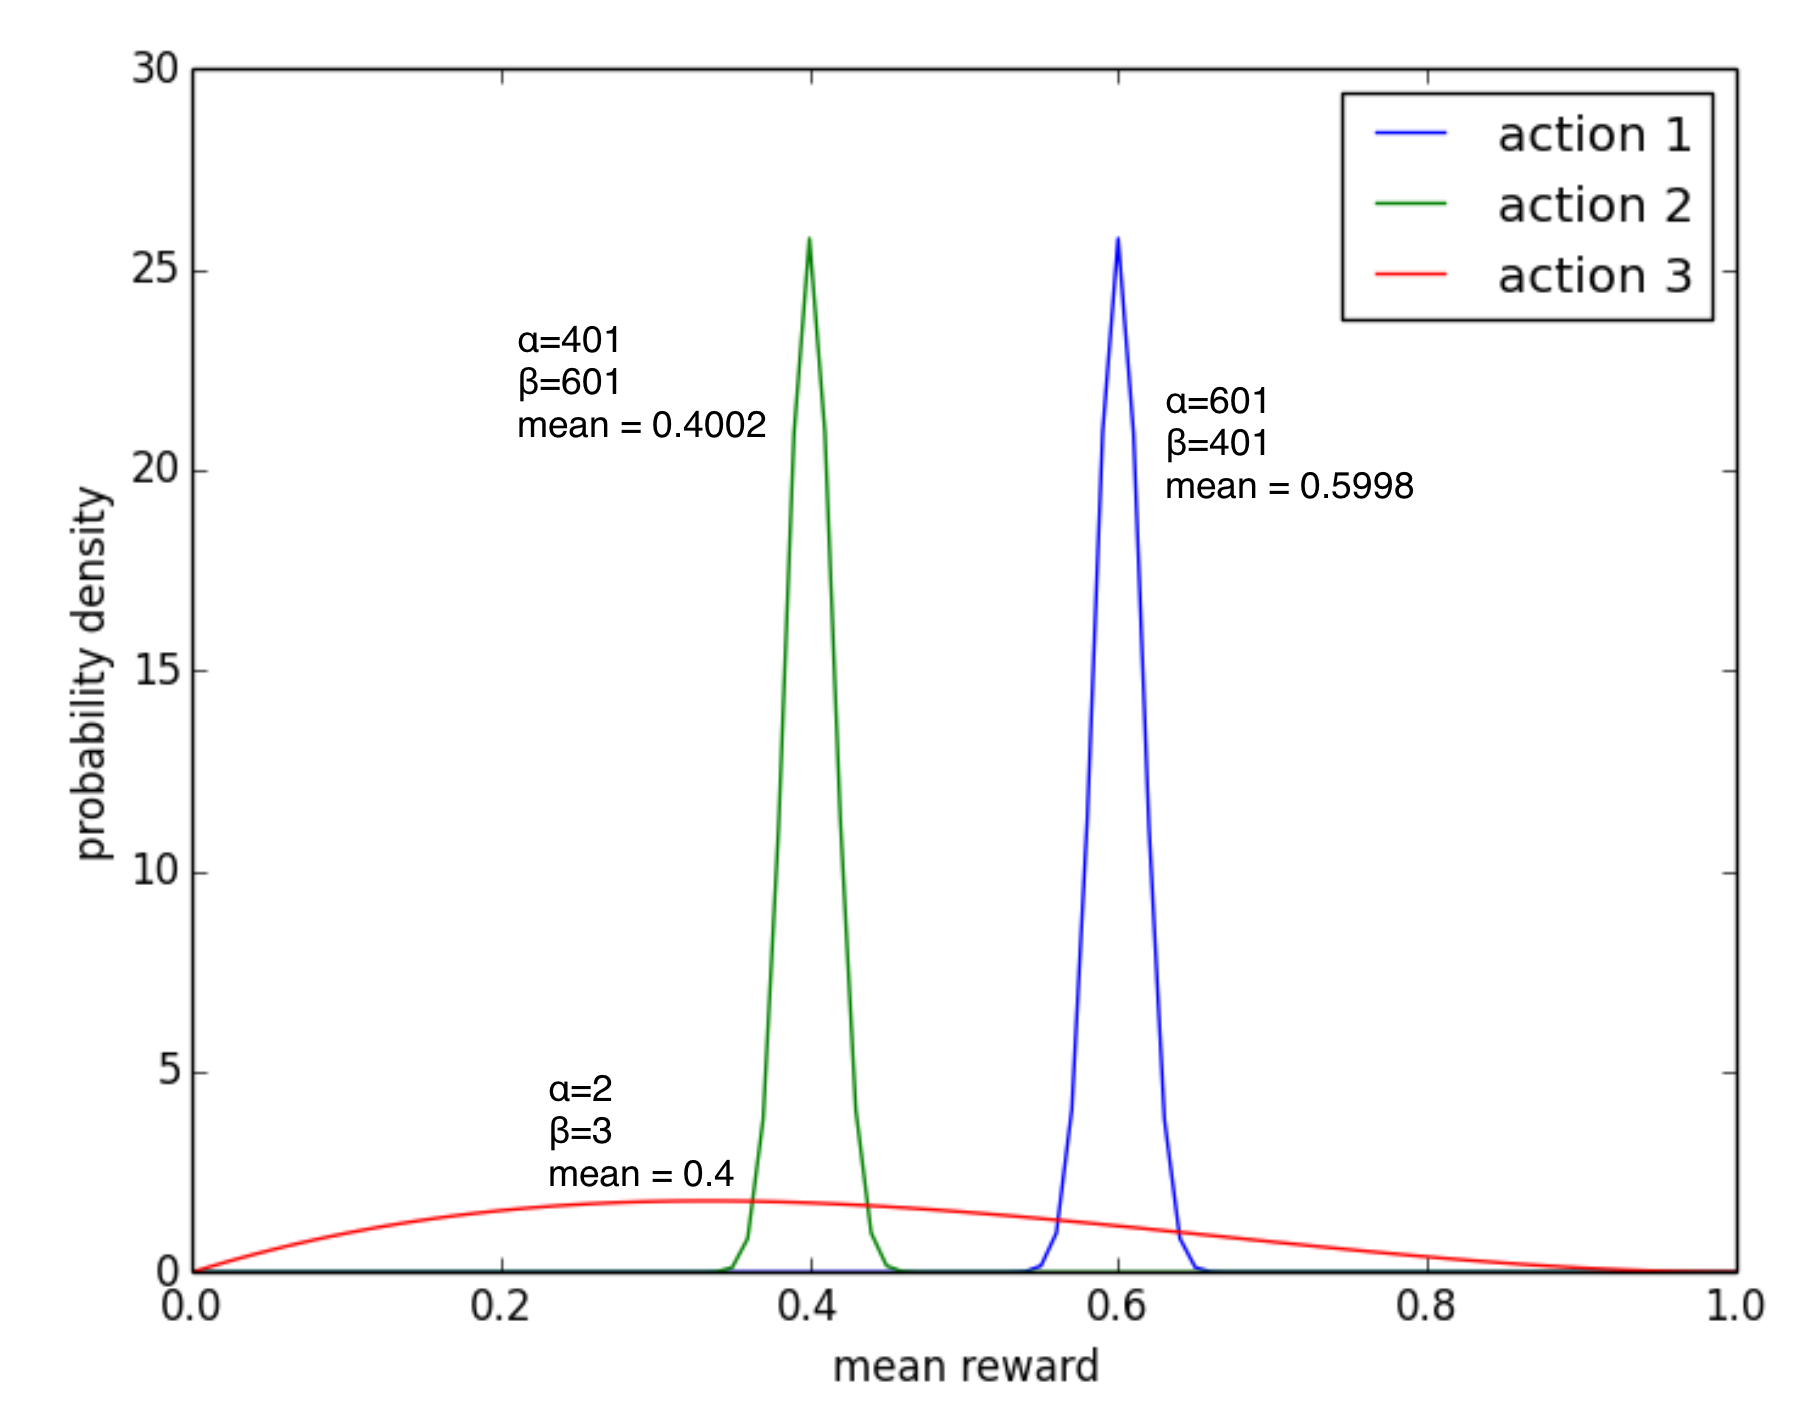

In [2]:
import matplotlib.pyplot as plt
import scipy

In [3]:
from scipy.stats import beta

dist1 = beta(601, 401)
dist2 = beta(401, 601)
dist3 = beta(2, 3)

num_samples = 1000

In [4]:
samples1 = dist1.rvs(size=num_samples)
samples2 = dist2.rvs(size=num_samples)
samples3 = dist3.rvs(size=num_samples)

In [5]:
np.mean((samples1 > samples2) & (samples1 > samples3))

np.float64(0.816)

In [6]:
np.mean((samples2 > samples1) & (samples2 > samples3))

np.float64(0.0)

In [7]:
np.mean((samples3 > samples1) & (samples3 > samples1))

np.float64(0.184)

# Theoretical result

ref: https://chatgpt.com/share/69a70b16-5b9c-8012-8a2e-352edbf2f83b

In [8]:
from scipy.stats import beta
import numpy as np
from scipy.integrate import quad

# Example Beta parameters
alpha = [601, 401, 2]
beta_params = [401, 601, 3]

# Define functions for each integral
def P_largest(i):
    f_i = lambda x: beta.pdf(x, alpha[i], beta_params[i])
    F_others = lambda x: np.prod([beta.cdf(x, alpha[j], beta_params[j]) 
                                  for j in range(3) if j != i])
    integrand = lambda x: f_i(x) * F_others(x)
    return quad(integrand, 0, 1)[0]

probs = [P_largest(i) for i in range(3)]
print("Probabilities of being largest:", probs)
print("Sum (should be ~1):", sum(probs))

Probabilities of being largest: [0.8201111911065548, 1.0257469705620772e-19, 0.17988880889359588]
Sum (should be ~1): 1.0000000000001508
